# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

In [1]:
# 1.1. Importando MNIST:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target
print("Finalizou o processo de baixar o dataset MNIST!")

print(f"Dimensionalidade dos dados (X): {X.shape}")
print(f"Dimensionalidade dos rótulos (y): {y.shape}")


Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!
Dimensionalidade dos dados (X): (70000, 784)
Dimensionalidade dos rótulos (y): (70000,)


In [2]:
# 1.2. Distribuição das classes (0 a 9)
class_counts = pd.Series(y).value_counts().sort_index()

print("Distribuição das Classes (Dígitos):")
print(class_counts)


Distribuição das Classes (Dígitos):
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


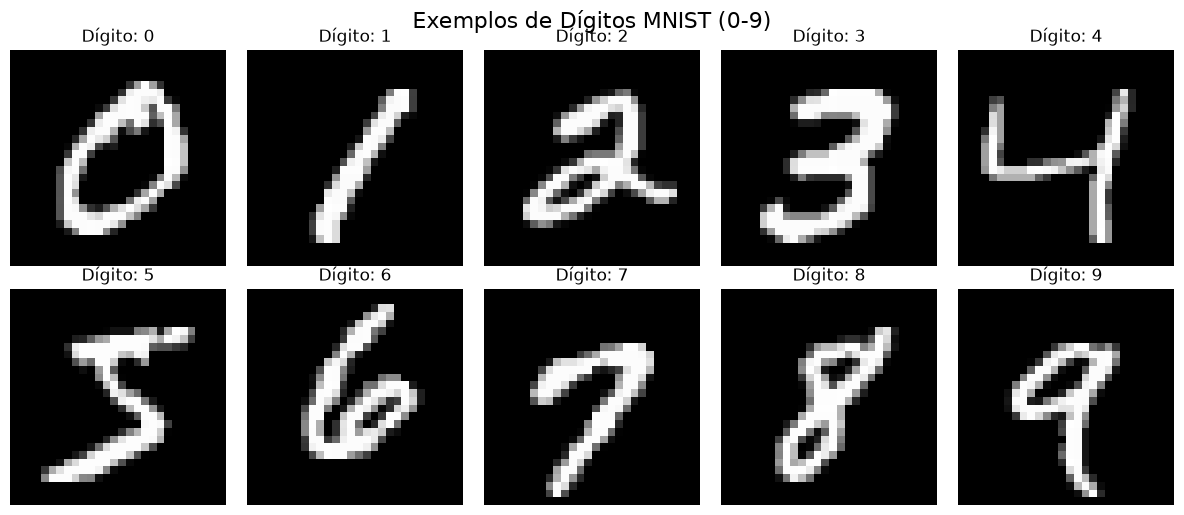

In [3]:
# 1.3. Visualização dos exemplos de imagens de cada digito, com rotulos:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Encontrar um exemplo para cada dígito de 0 a 9
seen_labels = []
example_indices = []

for i in range(len(y)):
    label = y[i]
    if label not in seen_labels:
        seen_labels.append(label)
        example_indices.append(i)
    if len(seen_labels) == 10:
        break

# Colocando em ordem para exibição:
example_indices_sorted = [idx for _, idx in sorted(zip([int(y[i]) for i in example_indices], example_indices))]

for i, idx in enumerate(example_indices_sorted):
    ax = axes[i]
    ax.imshow(X[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Dígito: {y[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.suptitle('Exemplos de Dígitos MNIST (0-9)', y=1.02, fontsize=16)
plt.show()


# 1.4. Interpretação da Estrutura dos Dados

O dataset MNIST é composto por imagens de dígitos manuscritos. Cada imagem tem as seguintes características:

*   Formato: Cada imagem é uma grade de 28x28 pixels.
*   Pixels: Cada pixel possui um valor de intensidade que varia de 0 a 255. Onde:
    *   '0': Representa o preto (ausência de tinta).
    *   '255': Representa o branco (presença máxima de tinta).
    *   Valores intermediários: Representam tons de cinza.
*   Representação Vetorial: Para que os algoritmos de Machine Learning possam processar essas imagens, cada imagem bidimensional (28x28) é 'achatada' em um único vetor unidimensional de 784 características (28 * 28 = 784). Cada uma dessas 784 características corresponde à intensidade de um pixel na imagem original. Isso significa que, para cada imagem, temos uma linha de 784 números, ou pixels.

X contém 70.000 imagens vetorizadas, cada uma com 784 características. y contém os rótulos destas imagens.

# Fase 2: Pipeline de Pré-processamento e Divisão dos Dados

In [4]:
# 2.1. Divisão Estratificada:
from sklearn.model_selection import train_test_split

#Divisão do dataset em treino/validação e teste (80% treino/validação, 20% teste)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Conjunto de Treino + Validação (X_train_val): {X_train_val.shape}")
print(f"Conjunto de Teste (X_test): {X_test.shape}")
print(f"Conjunto dos rótulos de Treino + Validação (y_train_val): {y_train_val.shape}")
print(f"Conjunto dos rótulos de Teste (y_test): {y_test.shape}")

Conjunto de Treino + Validação (X_train_val): (56000, 784)
Conjunto de Teste (X_test): (14000, 784)
Conjunto dos rótulos de Treino + Validação (y_train_val): (56000,)
Conjunto dos rótulos de Teste (y_test): (14000,)


In [6]:
# 2.2. Normalização/Escalonamento (dividindo por 255.0 para escalar os pixels para o intervalo [0.0, 1.0])
X_train_val_scaled = X_train_val / 255.0
X_test_scaled = X_test / 255.0

print(f"Valor máximo de pixel em X_train_val_scaled: {X_train_val_scaled.max()}")
print(f"Valor mínimo de pixel em X_train_val_scaled: {X_train_val_scaled.min()}")
print(f"Valor máximo de pixel em X_test_scaled: {X_test_scaled.max()}")
print(f"Valor mínimo de pixel em X_test_scaled: {X_test_scaled.min()}")

Valor máximo de pixel em X_train_val_scaled: 1.0
Valor mínimo de pixel em X_train_val_scaled: 0.0
Valor máximo de pixel em X_test_scaled: 1.0
Valor mínimo de pixel em X_test_scaled: 0.0


In [7]:
# Divisão do dataset em treino e validação (70% treino, 10% validação)
X_train, X_val, y_train, y_val = train_test_split(X_train_val_scaled, y_train_val, test_size=(0.1/0.8), stratify=y_train_val, random_state=42) # 0.125 * 0.8 = 0.1 do total

print(f"Conjunto de Treino (X_train): {X_train.shape}")
print(f"Conjunto de Validação (X_val): {X_val.shape}")
print(f"Conjunto dos rótulos de Treino (y_train): {y_train.shape}")
print(f"Conjunto dos rótulos de Validação (y_val): {y_val.shape}")

Conjunto de Treino (X_train): (49000, 784)
Conjunto de Validação (X_val): (7000, 784)
Conjunto dos rótulos de Treino (y_train): (49000,)
Conjunto dos rótulos de Validação (y_val): (7000,)



# 2.3. Importância da Normalização

   **Convergência de Modelos Lineares**: Algoritmos de modelos lineares (regressao logistica, por ex.) convergem muito mais rapidamente quando as características estão em uma escala similar. Escalas muito diferentes podem levar a overfitting, aumentar o tempo de treinamento e a chance de encontrar um mínimo local indesejado.
   
   **Distâncias Métricas**: Algoritmos que dependem do cálculo de distâncias entre pontos (ex: K-Nearest Neighbors - KNN, K-Means) são sensíveis à escala das características. Se uma característica tem uma amplitude de valores muito maior que outra, ela pode dominar o cálculo da distância, subestimando a importância de outras características. A normalização garante que todas as características contribuam igualmente para a medida de distância


# Fase 3: Implementação e Treinamento dos 3 Modelos

Obs.: A escolha dos modelos se baseou na limitação do recurso disponível. 

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 3.1. Modelo 1: K-Nearest Neighbors (KNN)
print("\nTreinando o modelo K-Nearest Neighbors (KNN)...")
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance') 
# Ajuste justificado: n_neighbors (número de vizinhos) e weights (como os vizinhos contribuem)
knn_model.fit(X_train, y_train)
print("KNN treinado com sucesso!")

# 3.2. Modelo 2: Regressão Logística
print("\nTreinando o modelo de Regressão Logística...")
# Ajuste justificado: C (força de regularização) e solver (algoritmo de otimização)
# max_iter aumentado para garantir convergência
log_reg_model = LogisticRegression(C=0.1, solver='sag', max_iter=500, random_state=42)
log_reg_model.fit(X_train, y_train)
print("Regressão Logística treinada com sucesso!")

# 3.3. Modelo 3: Random Forest Classifier
print("\nTreinando o modelo Random Forest Classifier...")
# Ajuste justificado: n_estimators (número de árvores) e max_depth (profundidade máxima da árvore)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest treinado com sucesso!")


Treinando o modelo K-Nearest Neighbors (KNN)...
KNN treinado com sucesso!

Treinando o modelo de Regressão Logística...
Regressão Logística treinada com sucesso!

Treinando o modelo Random Forest Classifier...
Random Forest treinado com sucesso!


# Fase 4: Avaliação Comparativa de Desempenho

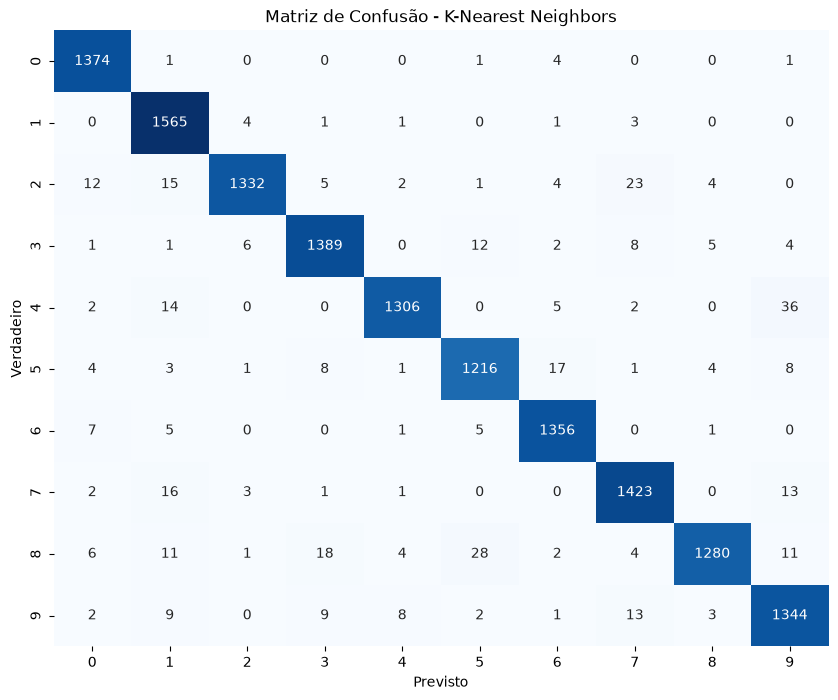


Relatório de Classificação - K-Nearest Neighbors:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.95      0.99      0.97      1575
           2       0.99      0.95      0.97      1398
           3       0.97      0.97      0.97      1428
           4       0.99      0.96      0.97      1365
           5       0.96      0.96      0.96      1263
           6       0.97      0.99      0.98      1375
           7       0.96      0.98      0.97      1459
           8       0.99      0.94      0.96      1365
           9       0.95      0.97      0.96      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



In [10]:
# 4.1. Métricas do Modelo KNN

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Previsões no conjunto de teste
y_pred_knn = knn_model.predict(X_test_scaled)

# Matriz de Confusão
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=knn_model.classes_, yticklabels=knn_model.classes_)
plt.title('Matriz de Confusão - K-Nearest Neighbors')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()

# Relatório de Classificação
print("\nRelatório de Classificação - K-Nearest Neighbors:\n")
print(classification_report(y_test, y_pred_knn))



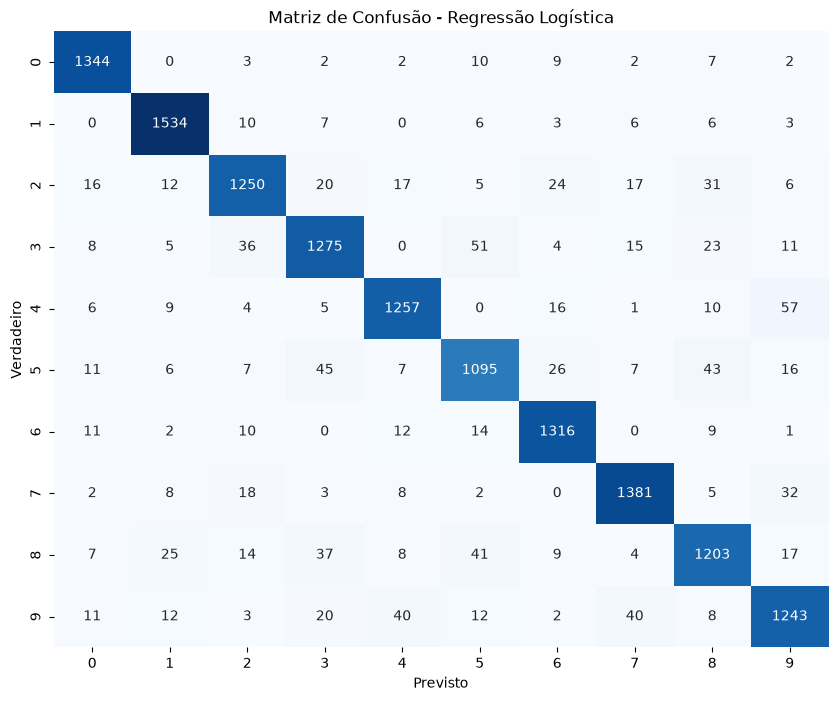


Relatório de Classificação - Regressão Logística:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.95      0.97      0.96      1575
           2       0.92      0.89      0.91      1398
           3       0.90      0.89      0.90      1428
           4       0.93      0.92      0.93      1365
           5       0.89      0.87      0.88      1263
           6       0.93      0.96      0.95      1375
           7       0.94      0.95      0.94      1459
           8       0.89      0.88      0.89      1365
           9       0.90      0.89      0.89      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



In [11]:
# 4.2. Métricas do Modelo de Regressão Logística

# Previsões no conjunto de teste
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

# Matriz de Confusão
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=log_reg_model.classes_, yticklabels=log_reg_model.classes_)
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()

# Relatório de Classificação
print("\nRelatório de Classificação - Regressão Logística:\n")
print(classification_report(y_test, y_pred_log_reg))



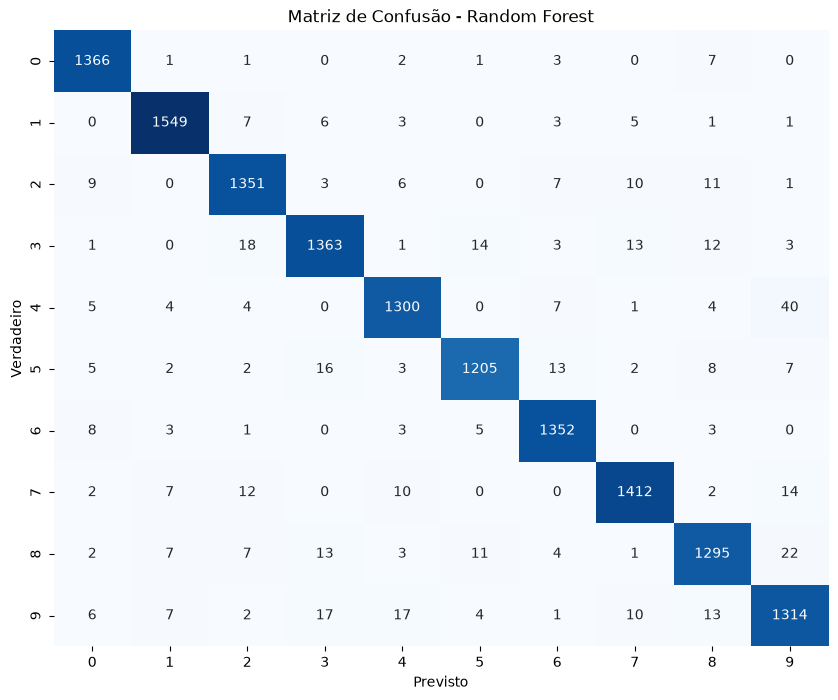


Relatório de Classificação - Random Forest:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.97      0.96      1398
           3       0.96      0.95      0.96      1428
           4       0.96      0.95      0.96      1365
           5       0.97      0.95      0.96      1263
           6       0.97      0.98      0.98      1375
           7       0.97      0.97      0.97      1459
           8       0.96      0.95      0.95      1365
           9       0.94      0.94      0.94      1391

    accuracy                           0.96     14000
   macro avg       0.96      0.96      0.96     14000
weighted avg       0.96      0.96      0.96     14000



In [12]:
# 4.3. Métricas do Modelo Random Forest

# Previsões no conjunto de teste
y_pred_rf = rf_model.predict(X_test_scaled)

# Matriz de Confusão
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()

# Relatório de Classificação
print("\nRelatório de Classificação - Random Forest:\n")
print(classification_report(y_test, y_pred_rf))



In [13]:
# 4.4. Tabela Comparativa

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


metrics = {
    'KNN': {
        'Accuracy': accuracy_score(y_test, y_pred_knn),
        'Precision': precision_score(y_test, y_pred_knn, average='weighted'),
        'Recall': recall_score(y_test, y_pred_knn, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred_knn, average='weighted')
    },
    'Regressão Logística': {
        'Accuracy': accuracy_score(y_test, y_pred_log_reg),
        'Precision': precision_score(y_test, y_pred_log_reg, average='weighted'),
        'Recall': recall_score(y_test, y_pred_log_reg, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred_log_reg, average='weighted')
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf, average='weighted'),
        'Recall': recall_score(y_test, y_pred_rf, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred_rf, average='weighted')
    }
}

# Tabela comparativa
df_metrics = pd.DataFrame(metrics).T
display(df_metrics)


,Accuracy,Precision,Recall,F1-Score
KNN,0.970357,0.970664,0.970357,0.970323
Regressão Logística,0.921286,0.920969,0.921286,0.921040
Random Forest,0.964786,0.964787,0.964786,0.964760


# 4.5. Conclusões

Avaliando os três modelos, KNN, Regressão Logística e Random Forest no conjunto de teste, podemos concluir que:

i.  Maior Taxa de Confusão:
    
    O dígito 4 apresentou a maior taxa de confusão, sendo frequentemente previsto como 9 por todos os modelos. No KNN, 36 instâncias de 4 foram classificadas como 9. Na Regressão Logística, esse número subiu para 57, e no Random Forest, 40 instâncias de 4 foram classificadas como 9. O dígito 2 também foi confundido com o 7, no KNN, e 8, na Regressão Logística, e o 5 com o 3, na Regressão Logística.

ii.  Melhor Performance:

    O modelo KNN obteve a melhor performance com uma Acurácia de aproximadamente 97,04%, Precisão de 97.07%, Recall de 97.04% e F1-Score de 97.03%. Na sequencia, o Random Forest apresentou valores um pouco menores, em torno de 96.5% para todas as métricas, enquanto a Regressão apresentou uma performande inferior, com valores em torno de 92.1%.

iii.  Impacto do Custo Computacional (Tempo de Treino vs. Acurácia):
    
    O KNN possui um tempo de treino quase instantâneo, enquanto a Regressão Logística apresentou o maior tempo de execução, além da menor acurácia neste conjunto de dados.
    O Random Forest apresentou tempo intermediaroi e boa performance.
    Portanto, para esta abordagem específica, o modelo mais eficaz entre os 3 escolhidos, foi  o KNN, o que sugere que as distancias entre as imagens contem informações relevantes para essa classificação. 

# Fase 5 : Teste da capacidade dos modelos de lidar com cenários fora do padrão ideal de laboratório

# 5.1. Desafio (A) Treinamento Restrito com Classes Ocultadas (Class Masking)

In [15]:
# Ocultando os dígitos 4 e 7:
masked_classes = ['4', '7'] 

# Criar filtros com máscaras booleanas para os dados de treino e validação:

mask_train = ~np.isin(y_train, masked_classes)
X_train_masked = X_train[mask_train]
y_train_masked = y_train[mask_train]

mask_val = ~np.isin(y_val, masked_classes)
X_val_masked = X_val[mask_val]
y_val_masked = y_val[mask_val]

print(f"Original X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Masked X_train_masked shape: {X_train_masked.shape}, y_train_masked shape: {y_train_masked.shape}")
print(f"Original X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"Masked X_val_masked shape: {X_val_masked.shape}, y_val_masked shape: {y_val_masked.shape}")

# Treinando o Random Forest:

import time

print("\nTreinando o Random Forest com Class Masking...")
start_time = time.time()

rf_model_masked = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
rf_model_masked.fit(X_train_masked, y_train_masked)

end_time = time.time()
training_time = end_time - start_time

print(f"Random Forest (Masked Classes) treinado com sucesso em {training_time:.2f} segundos!")

Original X_train shape: (49000, 784), y_train shape: (49000,)
Masked X_train_masked shape: (39118, 784), y_train_masked shape: (39118,)
Original X_val shape: (7000, 784), y_val shape: (7000,)
Masked X_val_masked shape: (5589, 784), y_val_masked shape: (5589,)

Treinando o Random Forest com Class Masking...
Random Forest (Masked Classes) treinado com sucesso em 65.49 segundos!


# 5.2. Desafio (B) Teste de Generalização Extrema (Inferência OOD)

X_test_ood shape: (2824, 784), y_test_ood shape: (2824,)


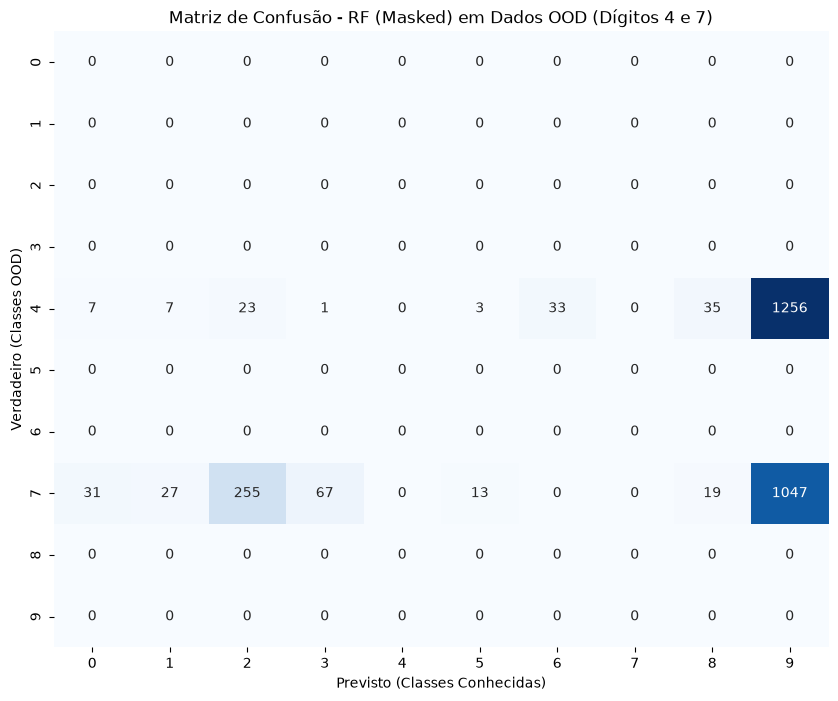

In [17]:
# Considerar agora apenas as classes ocultadas (4 e 7)
ood_classes = ['4', '7']

mask_test_ood = np.isin(y_test, ood_classes)
X_test_ood = X_test_scaled[mask_test_ood]
y_test_ood = y_test[mask_test_ood]

print(f"X_test_ood shape: {X_test_ood.shape}, y_test_ood shape: {y_test_ood.shape}")


y_pred_ood = rf_model_masked.predict(X_test_ood)

# Garantir que os arrays labels sejam strings 
y_test_ood_str = np.array(y_test_ood, dtype=str)
y_pred_ood_str = np.array(y_pred_ood, dtype=str)
all_digits_str = np.array([str(i) for i in range(10)], dtype=str)

# Matriz de Confusão
cm_ood = confusion_matrix(y_test_ood_str, y_pred_ood_str, labels=all_digits_str)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_ood, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=all_digits_str, yticklabels=all_digits_str)
plt.title('Matriz de Confusão - RF (Masked) em Dados OOD (Dígitos 4 e 7)')
plt.xlabel('Previsto (Classes Conhecidas)')
plt.ylabel('Verdadeiro (Classes OOD)')
plt.show()

# Análise do Comportamento do Modelo no Cenário OOD

i. Como o classificador reage ao ser forçado a classificar algo que nunca viu?

    Ao submeter o modelo sem os digitos 4 e 7 a um teste que possui somente imagens desses dígitos ocultados, o modelo tenta classificá-los nas classes que ele conhece, que foi treinado. Ele não reconhece os dígitos 4 e 7  como 'desconhecidos' (classe inexistente). Portanto, ele atribui o rótulo conhecido mais provável com base nas características que ele aprendeu.
 
ii. Quais classes conhecidas ele atribui a esses dígitos desconhecidos?

        O dígito 4 (verdadeiro) foi predominantemente confundido com o dígito 9 (1256 vezes), e em menor grau com 8 (35 vezes) e 6 (33 vezes).
        O dígito 7 (verdadeiro) foi predominantemente confundido com o dígito 9 (1047 vezes) e 2 (255 vezes), e em menor grau com 3 (67 vezes).

iii. Sobre o conceito de "falsa certeza" (overconfidence) em modelos de IA:

    Como a maioria dos modelos tradicionais de Machine Learning, o Random Forest é projetado para produzir uma previsão para cada entrada, ele não tem um mecanismo para detectar exemplos *out-of-distribution* (OOD). Ele não sabe que não sabe. Por isso ele pode retornar uma alta probabilidade (overconfidence) para uma classe conhecida, mesmo quando a entrada corresponde a uma classe desconhecida.
    Neste exemplo dos dígitos 4 e 7, ele encaixa na classe conhecida que minimiza seu erro interno, baseado em características 'aproximadas'.
    No mundo real, a falsa certeza pode ser perigosa. Por exemplo, em sistemas de detecção de câncer treinado apenas em com tipos comuns de tumores. Um tipo raro pode ser classificado erroneamente como um tumor benigno (conhecido), com alta confiança, levando a um diagnóstico incorreto e atraso no tratamento. 
    As técnicas de *Out-of-Distribution Detection* (OOD Detection) onde o modelo traz a 'probabilidade' do acerto ou até mesmo retorne 'ND' (not defined ou unknown), minimizam o erro.


# 5.3 - Desafio (C) Inferência com Imagens Manuscritas Próprias